Load dataset using pandas and get proper context and target windows saved. Convert data into tensors after proplerly filled.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch

# Load the 2024-12 vintage
fred = pd.read_csv("FRED-MD_2024m12.csv", index_col=0)

# FORCE index to datetime and drop garbage rows
fred.index = pd.to_datetime(fred.index, errors="coerce")
fred = fred.loc[fred.index.notna()]

# Fill Nans with previous values or after value if necessary
fred = fred.ffill().bfill()


# Context window: 60 months
context_start = "4/1/1981"
context_end   = "11/1/2023"
context_df = fred.loc[context_start:context_end]

# Target window: next 12 months
target_start = "12/1/2023"
target_end   = "11/1/2024"
target_df = fred.loc[target_start:target_end]

# Check to make sure we have correct shape
print("Context shape:", context_df.shape)
print("Target shape:", target_df.shape)

# Check make sure columsn are legit
print(fred.columns)

# Standard scale the data
scaler = StandardScaler()
scaler.fit(context_df.values)  # fit only on context

# Subtract mean divide by standard deviation
context_scaled = scaler.transform(context_df.values)
target_scaled  = scaler.transform(target_df.values)

# Convert to tensors: (num_series, time)
context_tensor = torch.tensor(context_scaled.T, dtype=torch.float32)
target_tensor  = torch.tensor(target_scaled.T, dtype=torch.float32)

# Print to make sure we have right sizes
print("Context tensor shape:", context_tensor.shape)  # (num_series, 60)
print("Target tensor shape:", target_tensor.shape)    # (num_series, 12)
print("Any NaNs left?", torch.isnan(context_tensor).any().item(), torch.isnan(target_tensor).any().item())



Context shape: (512, 126)
Target shape: (12, 126)
Index(['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO',
       'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD',
       ...
       'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008',
       'CES3000000008', 'UMCSENTx', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST',
       'VIXCLSx'],
      dtype='object', length=126)
Context tensor shape: torch.Size([126, 512])
Target tensor shape: torch.Size([126, 12])
Any NaNs left? False False


/tmp/ipython-input-1009710125.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fred.index = pd.to_datetime(fred.index, errors="coerce")


In [2]:
!pip install -q autogluon.timeseries

from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
import pandas as pd

# Your data is already loaded, but AutoGluon needs long format
# Let's assume fred has a DatetimeIndex and columns = variables

df_long = (
    fred
    .reset_index()
    .melt(id_vars=fred.index.name or "index",
          var_name="item_id",
          value_name="target")
    .rename(columns={fred.index.name or "index": "timestamp"})
)

ts_df = TimeSeriesDataFrame(df_long)

predictor = TimeSeriesPredictor(
    prediction_length=12,
    target="target",
    eval_metric="RMSE"
).fit(
    ts_df,
    hyperparameters={
        "Chronos": {
            "model_path": "amazon/chronos-bolt-tiny"
        }
    }
)

predictions = predictor.predict(ts_df)


Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20260201_142931'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Pytorch Version:    2.9.0+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 14.74/14.74 GB
Total GPU Memory:   Free: 14.74 GB, Allocated: 0.00 GB, Total: 14.74 GB
GPU Count:          1
Memory Avail:       10.92 GB / 12.67 GB (86.2%)
Disk Space Avail:   196.35 GB / 235.68 GB (83.3%)

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'hyperparameters': {'Chronos': {'model_path': 'amazon/chronos-bolt-tiny'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 12,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': Fa

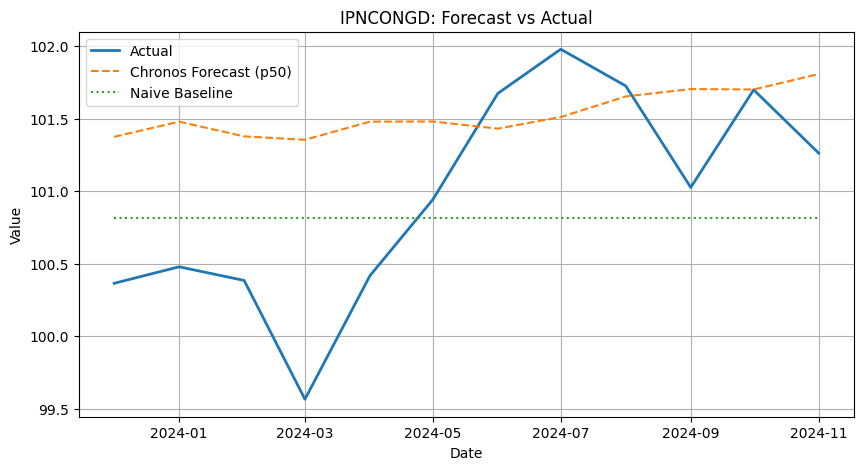

RMSE Forecast (p50): 0.85, RMSE Baseline: 0.72


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. Pick a representative series ---
series_id = "IPNCONGD"  # choose any column from your dataset

# --- 2. Extract actual values for that series ---
actual = fred[series_id].loc["12/1/2023":"11/1/2024"]

# --- 3. Extract predicted values from AutoGluon (using the median '0.5' quantile) ---
# AutoGluon's predictions DataFrame typically includes columns like 'mean', '0.1', '0.5', '0.9'
# We'll use the '0.5' quantile (median) for comparison.
preds_series = predictions.loc[series_id, '0.5'] if hasattr(predictions, "loc") else predictions[series_id]['0.5']

# --- 4. Naive baseline (last observed value from context) ---
baseline = np.full_like(actual, fill_value=context_df[series_id].iloc[-1])

# --- 5. Plot ---
plt.figure(figsize=(10,5))
plt.plot(actual.index, actual.values, label="Actual", linewidth=2)
plt.plot(actual.index, preds_series.values, label="Chronos Forecast (p50)", linestyle="--")
plt.plot(actual.index, baseline, label="Naive Baseline", linestyle=":")
plt.title(f"{series_id}: Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# --- 6. Optional RMSE ---
rmse_forecast = np.sqrt(mean_squared_error(actual.values, preds_series.values))
rmse_baseline = np.sqrt(mean_squared_error(actual.values, baseline))
print(f"RMSE Forecast (p50): {rmse_forecast:.2f}, RMSE Baseline: {rmse_baseline:.2f}")

Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20260201_142942'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Pytorch Version:    2.9.0+cu126
CUDA Version:       12.6
GPU Memory:         GPU 0: 14.73/14.74 GB
Total GPU Memory:   Free: 14.73 GB, Allocated: 0.01 GB, Total: 14.74 GB
GPU Count:          1
Memory Avail:       10.42 GB / 12.67 GB (82.2%)
Disk Space Avail:   196.35 GB / 235.68 GB (83.3%)

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'hyperparameters': {'Chronos': {'model_path': 'amazon/chronos-bolt-tiny'},
                     'DeepAR': {},
                     'PatchTST': {}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 12,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0

Generating predictions for model: Chronos[amazon__chronos-bolt-tiny]
Generating predictions for model: DeepAR
Generating predictions for model: PatchTST
Generating predictions for model: WeightedEnsemble


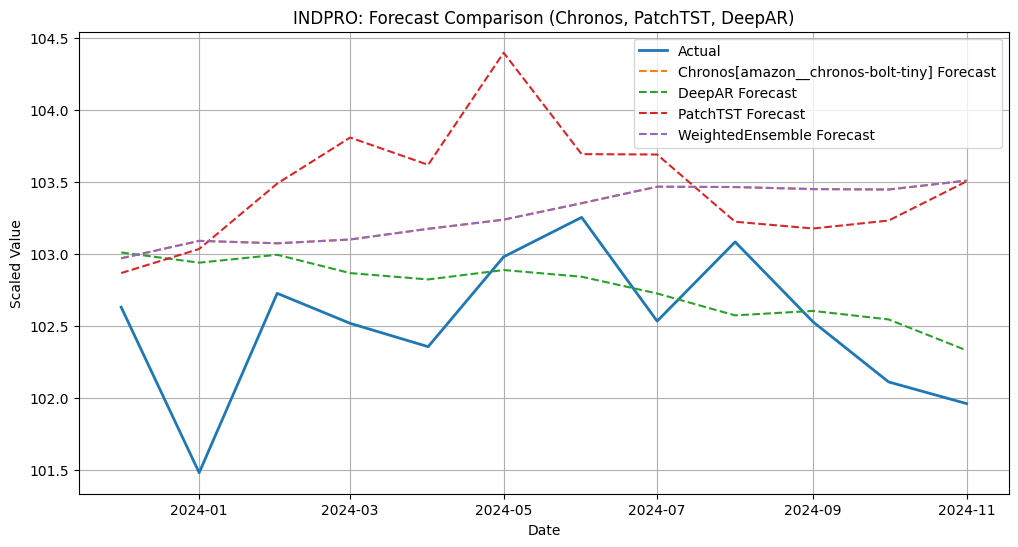


--- RMSE Comparison ---
Chronos[amazon__chronos-bolt-tiny] RMSE: 0.91
DeepAR RMSE: 0.54
PatchTST RMSE: 1.08
WeightedEnsemble RMSE: 0.91


In [4]:
from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. Convert your data to long format, using only the context_df for training ---
df_long = (
    context_df.reset_index() # Use context_df instead of fred
        .melt(id_vars=context_df.index.name or "index", # Use context_df.index.name
              var_name="item_id",
              value_name="target")
        .rename(columns={context_df.index.name or "index": "timestamp"}) # Use context_df.index.name
)
ts_df = TimeSeriesDataFrame(df_long)

# --- 2. Define hyperparameters for multiple models ---
# Each entry in this dictionary corresponds to a model to be trained.
# AutoGluon will train and evaluate each of these individually.
hyperparameters = {
    "Chronos": {"model_path": "amazon/chronos-bolt-tiny"}, # A specific pre-trained Chronos model
    "PatchTST": {},                                      # AutoGluon's PatchTST implementation
    "DeepAR": {},                                        # AutoGluon's DeepAR implementation
}

# --- 3. Initialize and fit the predictor with multiple models ---
# AutoGluon will train all models specified in 'hyperparameters'.
predictor = TimeSeriesPredictor(
    prediction_length=12, # This sets the prediction window to 12 months
    target="target",
    eval_metric="RMSE"
).fit(ts_df, hyperparameters=hyperparameters)

# --- 4. Make predictions for each model individually ---
# We retrieve the names of all trained models and then predict using each one.
model_names = predictor.model_names()
preds_dict = {}
for model_name in model_names:
    print(f"Generating predictions for model: {model_name}")
    # The 'model' argument specifies which trained model to use for prediction.
    preds_dict[model_name] = predictor.predict(ts_df, model=model_name)

# --- 5. Pick a representative series for plotting and evaluation ---
series_id = "INDPRO"

# --- 6. Extract actual values for the chosen series ---
actual = fred[series_id].loc["12/1/2023":"11/1/2024"]

# --- 7. Plot each model's forecast vs actual ---
plt.figure(figsize=(12,6))
plt.plot(actual.index, actual.values, label="Actual", linewidth=2)

for model_name, preds in preds_dict.items():
    # Extract the 'mean' prediction for the chosen series from the TimeSeriesDataFrame.
    # AutoGluon's predict method for multiple models returns a TimeSeriesDataFrame where
    # predictions are indexed by item_id and timestamp.
    pred_series = preds.loc[preds.index.get_level_values("item_id") == series_id]["mean"].values
    plt.plot(actual.index, pred_series, linestyle="--", label=f"{model_name} Forecast")

plt.title(f"{series_id}: Forecast Comparison (Chronos, PatchTST, DeepAR)")
plt.xlabel("Date")
plt.ylabel("Scaled Value")
plt.legend()
plt.grid(True)
plt.show()

# --- 8. Compute RMSE for each model ---
print("\n--- RMSE Comparison ---")
for model_name, preds in preds_dict.items():
    # Again, extract the 'mean' prediction for RMSE calculation.
    pred_series = preds.loc[preds.index.get_level_values("item_id") == series_id]["mean"].values
    rmse = np.sqrt(mean_squared_error(actual.values, pred_series))
    print(f"{model_name} RMSE: {rmse:.2f}")

In [5]:
from sklearn.metrics import mean_absolute_error

def mase(y_true, y_pred, y_insample, m=12):
    """
    Mean Absolute Scaled Error (MASE)
    m = seasonal period (12 for monthly data)
    """
    naive_forecast = y_insample[m:]
    naive_actual = y_insample[:-m]
    naive_mae = np.mean(np.abs(naive_forecast - naive_actual))
    return np.mean(np.abs(y_true - y_pred)) / naive_mae


print("\n--- Metric Comparison (RMSE, MAE, MASE) ---")

# In-sample data for MASE scaling (history before forecast window)
insample = fred[series_id].loc[: "11/1/2023"].values

for model_name, preds in preds_dict.items():
    pred_series = preds.loc[
        preds.index.get_level_values("item_id") == series_id
    ]["mean"].values

    rmse = np.sqrt(mean_squared_error(actual.values, pred_series))
    mae = mean_absolute_error(actual.values, pred_series)
    mase_val = mase(actual.values, pred_series, insample, m=12)

    print(
        f"{model_name:25s} | "
        f"RMSE: {rmse:8.2f} | "
        f"MAE: {mae:8.2f} | "
        f"MASE: {mase_val:6.3f}"
    )



--- Metric Comparison (RMSE, MAE, MASE) ---
Chronos[amazon__chronos-bolt-tiny] | RMSE:     0.91 | MAE:     0.76 | MASE:  0.288
DeepAR                    | RMSE:     0.54 | MAE:     0.42 | MASE:  0.157
PatchTST                  | RMSE:     1.08 | MAE:     0.96 | MASE:  0.363
WeightedEnsemble          | RMSE:     0.91 | MAE:     0.76 | MASE:  0.288


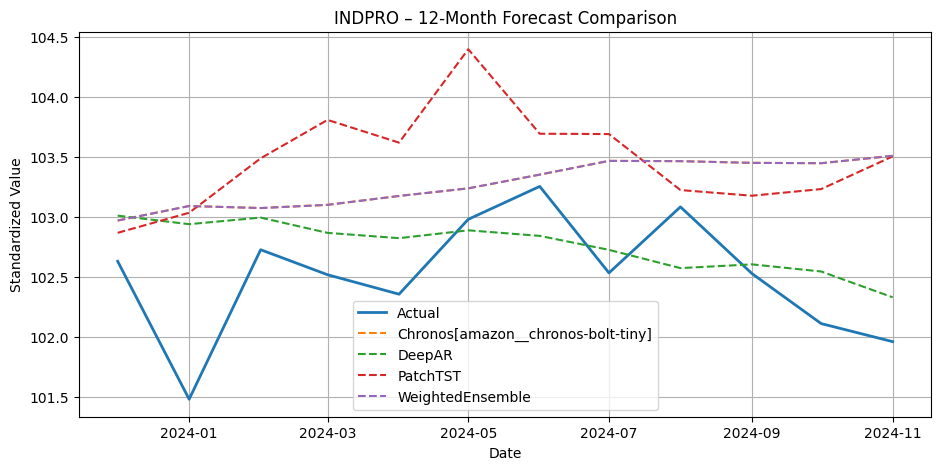

In [7]:
# ========= Forecast Plot (change series_id only) =========

import matplotlib.pyplot as plt

# 🔁 CHANGE THIS LINE ONLY
series_id = "INDPRO"   # e.g. "INDPRO", "IPNCONGD", "CPIAUCSL", etc.

# Actual values (target window)
actual = fred[series_id].loc["12/1/2023":"11/1/2024"]

plt.figure(figsize=(11, 5))
plt.plot(actual.index, actual.values, label="Actual", linewidth=2)

# Plot each model's forecast
for model_name, preds in preds_dict.items():
    pred_series = preds.loc[
        preds.index.get_level_values("item_id") == series_id
    ]["mean"].values

    plt.plot(
        actual.index,
        pred_series,
        linestyle="--",
        label=model_name
    )

plt.title(f"{series_id} – 12-Month Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.show()
